# 9.1 门控循环单元（GRU）
:label:`sec_gru`

在 :numref:`sec_bptt`中，
我们讨论了如何在循环神经网络中计算梯度，
以及矩阵连续乘积可以导致梯度消失或梯度爆炸的问题。
下面我们简单思考一下这种梯度异常在实践中的意义：

* 我们可能会遇到这样的情况：早期观测值对预测所有未来观测值具有非常重要的意义。
  考虑一个极端情况，其中第一个观测值包含一个校验和，
  目标是在序列的末尾辨别校验和是否正确。
  在这种情况下，第一个词元的影响至关重要。
  我们希望有某些机制能够在一个记忆元里存储重要的早期信息。
  如果没有这样的机制，我们将不得不给这个观测值指定一个非常大的梯度，
  因为它会影响所有后续的观测值。
* 我们可能会遇到这样的情况：一些词元没有相关的观测值。
  例如，在对网页内容进行情感分析时，
  可能有一些辅助HTML代码与网页传达的情绪无关。
  我们希望有一些机制来*跳过*隐状态表示中的此类词元。
* 我们可能会遇到这样的情况：序列的各个部分之间存在逻辑中断。
  例如，书的章节之间可能会有过渡存在，
  或者证券的熊市和牛市之间可能会有过渡存在。
  在这种情况下，最好有一种方法来*重置*我们的内部状态表示。

在学术界已经提出了许多方法来解决这类问题。
其中最早的方法是"长短期记忆"（long-short-term memory，LSTM）
 :cite:`Hochreiter.Schmidhuber.1997`，
我们将在 :numref:`sec_lstm`中讨论。
门控循环单元（gated recurrent unit，GRU）
 :cite:`Cho.Van-Merrienboer.Bahdanau.ea.2014`
是一个稍微简化的变体，通常能够提供同等的效果，
并且计算 :cite:`Chung.Gulcehre.Cho.ea.2014`的速度明显更快。
由于门控循环单元更简单，我们从它开始解读。

## 9.1.1 门控隐状态

门控循环单元与普通的循环神经网络之间的关键区别在于：
前者支持隐状态的门控。
这意味着模型有专门的机制来确定应该何时更新隐状态，
以及应该何时重置隐状态。
这些机制是可学习的，并且能够解决了上面列出的问题。
例如，如果第一个词元非常重要，
模型将学会在第一次观测之后不更新隐状态。
同样，模型也可以学会跳过不相关的临时观测。
最后，模型还将学会在需要的时候重置隐状态。
下面我们将详细讨论各类门控。

### 1. 重置门和更新门

我们首先介绍*重置门*（reset gate）和*更新门*（update gate）。
我们把它们设计成$(0, 1)$区间中的向量，
这样我们就可以进行凸组合。
重置门允许我们控制“可能还想记住”的过去状态的数量；
更新门将允许我们控制新状态中有多少个是旧状态的副本。

我们从构造这些门控开始。 :numref:`fig_gru_1`
描述了门控循环单元中的重置门和更新门的输入，
输入是由当前时间步的输入和前一时间步的隐状态给出。
两个门的输出是由使用sigmoid激活函数的两个全连接层给出。

![在门控循环单元模型中计算重置门和更新门](../img/gru-1.svg)
:label:`fig_gru_1`

我们来看一下门控循环单元的数学表达。
对于给定的时间步$t$，假设输入是一个小批量
$\mathbf{X}_t \in \mathbb{R}^{n \times d}$
（样本个数$n$，输入个数$d$），
上一个时间步的隐状态是
$\mathbf{H}_{t-1} \in \mathbb{R}^{n \times h}$
（隐藏单元个数$h$）。
那么，重置门$\mathbf{R}_t \in \mathbb{R}^{n \times h}$和
更新门$\mathbf{Z}_t \in \mathbb{R}^{n \times h}$的计算如下所示：

$$
\begin{aligned}
\mathbf{R}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xr} + \mathbf{H}_{t-1} \mathbf{W}_{hr} + \mathbf{b}_r),\\
\mathbf{Z}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xz} + \mathbf{H}_{t-1} \mathbf{W}_{hz} + \mathbf{b}_z),
\end{aligned}
$$

其中$\mathbf{W}_{xr}, \mathbf{W}_{xz} \in \mathbb{R}^{d \times h}$
和$\mathbf{W}_{hr}, \mathbf{W}_{hz} \in \mathbb{R}^{h \times h}$是权重参数，
$\mathbf{b}_r, \mathbf{b}_z \in \mathbb{R}^{1 \times h}$是偏置参数。
请注意，在求和过程中会触发广播机制
（请参阅 :numref:`subsec_broadcasting`）。
我们使用sigmoid函数（如 :numref:`sec_mlp`中介绍的）
将输入值转换到区间$(0, 1)$。

### 2. 候选隐状态

接下来，让我们将重置门$\mathbf{R}_t$
与 :eqref:`rnn_h_with_state`
中的常规隐状态更新机制集成，
得到在时间步$t$的*候选隐状态*（candidate hidden state）
$\tilde{\mathbf{H}}_t \in \mathbb{R}^{n \times h}$。

$$\tilde{\mathbf{H}}_t = \tanh(\mathbf{X}_t \mathbf{W}_{xh} + \left(\mathbf{R}_t \odot \mathbf{H}_{t-1}\right) \mathbf{W}_{hh} + \mathbf{b}_h),$$
:eqlabel:`gru_tilde_H`

其中$\mathbf{W}_{xh} \in \mathbb{R}^{d \times h}$
和$\mathbf{W}_{hh} \in \mathbb{R}^{h \times h}$是权重参数，
$\mathbf{b}_h \in \mathbb{R}^{1 \times h}$是偏置项，
符号$\odot$是Hadamard积（按元素乘积）运算符。
在这里，我们使用tanh非线性激活函数来确保候选隐状态中的值保持在区间$(-1, 1)$中。

与 :eqref:`rnn_h_with_state`相比，
 :eqref:`gru_tilde_H`中的$\mathbf{R}_t$和$\mathbf{H}_{t-1}$
的元素相乘可以减少以往状态的影响。
每当重置门$\mathbf{R}_t$中的项接近$1$时，
我们恢复一个如 :eqref:`rnn_h_with_state`中的普通的循环神经网络。
对于重置门$\mathbf{R}_t$中所有接近$0$的项，
候选隐状态是以$\mathbf{X}_t$作为输入的多层感知机的结果。
因此，任何预先存在的隐状态都会被*重置*为默认值。

 :numref:`fig_gru_2`说明了应用重置门之后的计算流程。

![在门控循环单元模型中计算候选隐状态](../img/gru-2.svg)
:label:`fig_gru_2`

### 3. 隐状态

上述的计算结果只是候选隐状态，我们仍然需要结合更新门$\mathbf{Z}_t$的效果。
这一步确定新的隐状态$\mathbf{H}_t \in \mathbb{R}^{n \times h}$
在多大程度上来自旧的状态$\mathbf{H}_{t-1}$和
新的候选状态$\tilde{\mathbf{H}}_t$。
更新门$\mathbf{Z}_t$仅需要在
$\mathbf{H}_{t-1}$和$\tilde{\mathbf{H}}_t$
之间进行按元素的凸组合就可以实现这个目标。
这就得出了门控循环单元的最终更新公式：

$$\mathbf{H}_t = \mathbf{Z}_t \odot \mathbf{H}_{t-1}  + (1 - \mathbf{Z}_t) \odot \tilde{\mathbf{H}}_t.$$

每当更新门$\mathbf{Z}_t$接近$1$时，模型就倾向只保留旧状态。
此时，来自$\mathbf{X}_t$的信息基本上被忽略，
从而有效地跳过了依赖链条中的时间步$t$。
相反，当$\mathbf{Z}_t$接近$0$时，
新的隐状态$\mathbf{H}_t$就会接近候选隐状态$\tilde{\mathbf{H}}_t$。
这些设计可以帮助我们处理循环神经网络中的梯度消失问题，
并更好地捕获时间步距离很长的序列的依赖关系。
例如，如果整个子序列的所有时间步的更新门都接近于$1$，
则无论序列的长度如何，在序列起始时间步的旧隐状态都将很容易保留并传递到序列结束。

 :numref:`fig_gru_3`说明了更新门起作用后的计算流。

![计算门控循环单元模型中的隐状态](../img/gru-3.svg)
:label:`fig_gru_3`

<span style="color:red;font-weight:600;font-size:15px">
    总之，门控循环单元具有以下两个显著特征：<br>
    &ensp;* 重置门有助于捕获序列中的短期依赖关系；<br>
    &ensp;* 更新门有助于捕获序列中的长期依赖关系。<br>
</span>
<span style="color:#6B8CBE;font-weight:600;font-size:16px">
    重置门决定是否要重置 $\mathbf{H}_{t-1}$ <br>
    更新门决定更新 $\mathbf{H}_{t-1}$ 的程度<br>
</span>

## 9.1.2 从零开始实现

为了更好地理解门控循环单元模型，我们从零开始实现它。
首先，我们读取 :numref:`sec_rnn_scratch`中使用的时间机器数据集：

In [51]:
import torch
from torch import nn
from d2l import torch as d2l

batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

### 1. 初始化模型参数

下一步是初始化模型参数。
我们从标准差为$0.01$的高斯分布中提取权重，
并将偏置项设为$0$，超参数`num_hiddens`定义隐藏单元的数量，
实例化与更新门、重置门、候选隐状态和输出层相关的所有权重和偏置。


In [52]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device)*0.01

    def three():
        return (normal((num_inputs, num_hiddens)),
                normal((num_hiddens, num_hiddens)),
                torch.zeros(num_hiddens, device=device))

    W_xz, W_hz, b_z = three()  # 更新门参数
    W_xr, W_hr, b_r = three()  # 重置门参数
    W_xh, W_hh, b_h = three()  # 候选隐状态参数
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

### 2. 定义模型

现在我们将[**定义隐状态的初始化函数**]`init_gru_state`。
与 :numref:`sec_rnn_scratch`中定义的`init_rnn_state`函数一样，
此函数返回一个形状为（批量大小，隐藏单元个数）的张量，张量的值全部为零。


In [53]:
def init_gru_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device), )

现在我们准备[**定义门控循环单元模型**]，
模型的架构与基本的循环神经网络单元是相同的，
只是权重更新公式更为复杂。


In [54]:
def gru(inputs, state, params):
    W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X in inputs:
        Z = torch.sigmoid((X @ W_xz) + (H @ W_hz) + b_z)
        R = torch.sigmoid((X @ W_xr) + (H @ W_hr) + b_r)
        H_tilda = torch.tanh((X @ W_xh) + ((R * H) @ W_hh) + b_h)
        H = Z * H + (1 - Z) * H_tilda
        Y = H @ W_hq + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

### 3. 训练与预测

训练和预测的工作方式与 :numref:`sec_rnn_scratch`完全相同。
训练结束后，我们分别打印输出训练集的困惑度，
以及前缀“time traveler”和“traveler”的预测序列上的困惑度。


困惑度 1.0, 71659.0 词元/秒 cpu
time traveller for so it will be convenient to speak of himwas e
travelleryou can show black is white by argument said filby


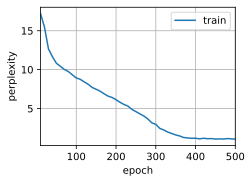

In [55]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1
model = d2l.RNNModelScratch(len(vocab), num_hiddens, device, get_params,
                            init_gru_state, gru)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

In [56]:
model.params

[tensor([[ 1.2585e-02,  1.5650e-02, -1.0751e-03,  ..., -3.1015e-02,
           2.1849e-02, -6.4956e-03],
         [ 7.0784e-02, -2.6482e-02, -9.2364e-02,  ..., -1.2500e-01,
           1.2925e-01,  4.9083e-02],
         [-2.7139e-03,  2.8674e-02,  2.6267e-01,  ...,  4.3949e-02,
           1.5355e-01, -1.8765e-02],
         ...,
         [ 4.1367e-03, -1.7468e-02,  1.5023e-02,  ..., -6.7404e-03,
           4.7760e-05,  6.8744e-03],
         [ 8.4982e-04,  3.4659e-03,  7.9869e-03,  ...,  2.8724e-04,
           1.9934e-03,  7.1354e-03],
         [-2.4316e-02, -7.5114e-03,  5.4920e-02,  ...,  9.3551e-04,
          -1.2892e-02, -4.8852e-03]], requires_grad=True),
 tensor([[-0.0580, -0.0021, -0.1303,  ..., -0.0053, -0.0105,  0.0327],
         [-0.0334,  0.0979, -0.0111,  ..., -0.0127,  0.0733,  0.1024],
         [-0.0949, -0.0272, -0.1601,  ...,  0.0927,  0.3124, -0.3311],
         ...,
         [-0.0238,  0.0432, -0.0607,  ...,  0.0184, -0.2045, -0.0504],
         [-0.0263, -0.0004,  0.0870,

Shape: torch.Size([28, 256])  |  Total elements: 7,168
Min: -0.961003  |  Max: 0.639392
Mean: -0.006540  |  Std: 0.076085
Median: -0.003998  |  IQR: 0.043986
Skewness: -0.5530  |  Kurtosis: 16.8844
Non-zero ratio: 100.0000%  |  |value| mean: 0.043228


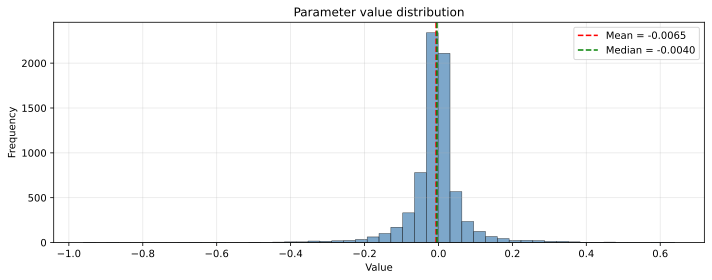

In [77]:
#W_xz
analyze_parameter_tensor(model.params[0], plot_hist=True, show_stats=True);

Shape: torch.Size([256, 256])  |  Total elements: 65,536
Min: -0.795612  |  Max: 1.017156
Mean: -0.000274  |  Std: 0.083960
Median: -0.000322  |  IQR: 0.078674
Skewness: 0.0358  |  Kurtosis: 5.7637
Non-zero ratio: 100.0000%  |  |value| mean: 0.057700


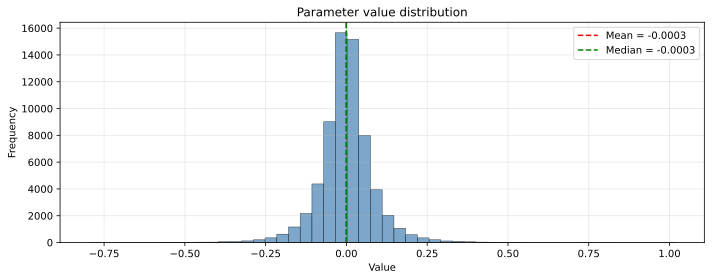

In [78]:
# W_hz
analyze_parameter_tensor(model.params[1], plot_hist=True, show_stats=True);

Shape: torch.Size([256])  |  Total elements: 256
Min: -0.852211  |  Max: 0.434063
Mean: -0.184634  |  Std: 0.142293
Median: -0.163479  |  IQR: 0.128631
Skewness: -0.7200  |  Kurtosis: 5.0208
Non-zero ratio: 100.0000%  |  |value| mean: 0.194384


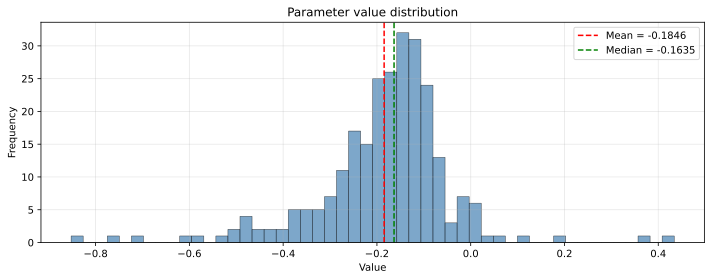

In [79]:
# b_z
analyze_parameter_tensor(model.params[2], plot_hist=True, show_stats=True);

----

Shape: torch.Size([28, 256])  |  Total elements: 7,168
Min: -1.198531  |  Max: 1.067492
Mean: 0.002444  |  Std: 0.082382
Median: 0.000810  |  IQR: 0.040316
Skewness: 0.1495  |  Kurtosis: 31.5254
Non-zero ratio: 100.0000%  |  |value| mean: 0.042078


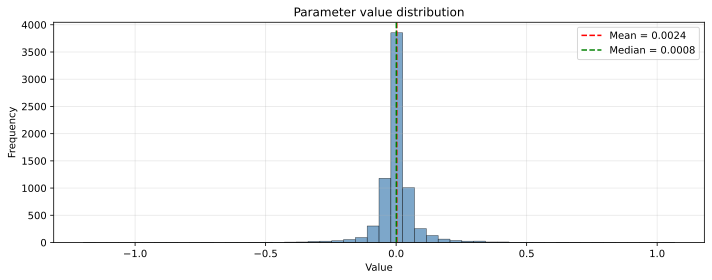

In [80]:
# W_xr
analyze_parameter_tensor(model.params[3], plot_hist=True, show_stats=True);

Shape: torch.Size([256, 256])  |  Total elements: 65,536
Min: -0.980430  |  Max: 0.701161
Mean: -0.000234  |  Std: 0.059346
Median: -0.000289  |  IQR: 0.056127
Skewness: -0.0647  |  Kurtosis: 7.4770
Non-zero ratio: 100.0000%  |  |value| mean: 0.040772


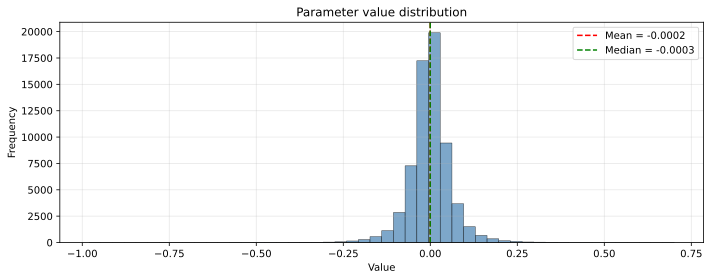

In [81]:
# W_hr
analyze_parameter_tensor(model.params[4], plot_hist=True, show_stats=True);

Shape: torch.Size([256])  |  Total elements: 256
Min: -0.364100  |  Max: 0.463489
Mean: 0.063958  |  Std: 0.102453
Median: 0.060727  |  IQR: 0.094059
Skewness: -0.4005  |  Kurtosis: 3.4600
Non-zero ratio: 100.0000%  |  |value| mean: 0.093243


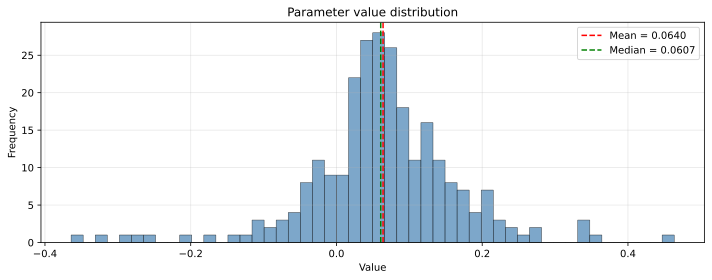

In [82]:
# b_r
analyze_parameter_tensor(model.params[5], plot_hist=True, show_stats=True);

## 9.1.3 简洁实现

高级API包含了前文介绍的所有配置细节，
所以我们可以直接实例化门控循环单元模型。
这段代码的运行速度要快得多，
因为它使用的是编译好的运算符而不是Python来处理之前阐述的许多细节。


困惑度 4.1, 99174.7 词元/秒 cpu
time traveller said the time traveller some thenght really sooke
travelleristencenthing he time traveller thing the time tra


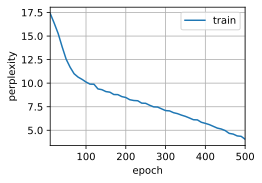

In [37]:
num_inputs = vocab_size
gru_layer = nn.GRU(num_inputs, num_hiddens)
model = d2l.RNNModel(gru_layer, len(vocab))
model = model.to(device)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

## 小结

* 门控循环神经网络可以更好地捕获时间步距离很长的序列上的依赖关系。
* 重置门有助于捕获序列中的短期依赖关系。
* 更新门有助于捕获序列中的长期依赖关系。
* 重置门打开时，门控循环单元包含基本循环神经网络；更新门打开时，门控循环单元可以跳过子序列。

## 练习

1. 假设我们只想使用时间步$t'$的输入来预测时间步$t > t'$的输出。对于每个时间步，重置门和更新门的最佳值是什么？
1. 调整和分析超参数对运行时间、困惑度和输出顺序的影响。
1. 比较`rnn.RNN`和`rnn.GRU`的不同实现对运行时间、困惑度和输出字符串的影响。
1. 如果仅仅实现门控循环单元的一部分，例如，只有一个重置门或一个更新门会怎样？


[Discussions](https://discuss.d2l.ai/t/2763)


### 1. 改变步长

In [16]:
batch_size, num_steps = 32, 100
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

num_inputs = vocab_size
gru_layer = nn.GRU(num_inputs, num_hiddens)
model = d2l.RNNModel(gru_layer, len(vocab))
model = model.to(device)
num_epochs, lr = 600, 1.5

困惑度 1.1, 107006.1 词元/秒 cpu
time traveller came excenarm the peoditil to me an ubreald disne
traveller after the pauserequired for the proper assimilati


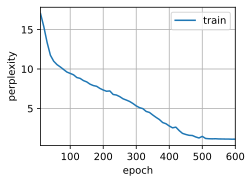

In [17]:
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

### 2. 仅实现门控循环单元的一部分

In [60]:
batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

1. 仅重置门(R)

In [61]:
def get_params_r(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device)*0.01

    def three():
        return (normal((num_inputs, num_hiddens)),
                normal((num_hiddens, num_hiddens)),
                torch.zeros(num_hiddens, device=device))

    
    W_xr, W_hr, b_r = three()  # 重置门参数
    W_xh, W_hh, b_h = three()  # 候选隐状态参数
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

In [62]:
def gru_r(inputs, state, params):
    W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X in inputs:
        #Z = torch.sigmoid((X @ W_xz) + (H @ W_hz) + b_z)
        R = torch.sigmoid((X @ W_xr) + (H @ W_hr) + b_r)
        H_tilda = torch.tanh((X @ W_xh) + ((R * H) @ W_hh) + b_h)
        #H = Z * H + (1 - Z) * H_tilda
        Y = H_tilda @ W_hq + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

困惑度 10.0, 145953.4 词元/秒 cpu
time travellere the the the the the the the the the the the the 
travellere the the the the the the the the the the the the 


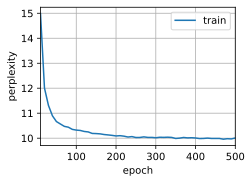

In [83]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1
model_r = d2l.RNNModelScratch(len(vocab), num_hiddens, device, get_params_r,
                            init_gru_state, gru_r)
d2l.train_ch8(model_r, train_iter, vocab, lr, num_epochs, device)

Shape: torch.Size([28, 256])  |  Total elements: 7,168
Min: -0.042003  |  Max: 0.037774
Mean: 0.000108  |  Std: 0.009995
Median: 0.000202  |  IQR: 0.013507
Skewness: 0.0027  |  Kurtosis: 0.0717
Non-zero ratio: 100.0000%  |  |value| mean: 0.007971


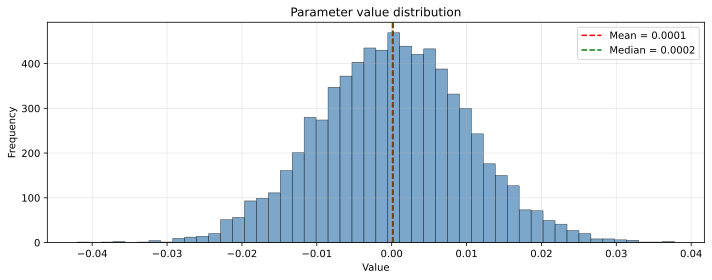

Shape: torch.Size([256, 256])  |  Total elements: 65,536
Min: -0.044165  |  Max: 0.042681
Mean: 0.000028  |  Std: 0.010022
Median: 0.000061  |  IQR: 0.013527
Skewness: -0.0078  |  Kurtosis: 0.0183
Non-zero ratio: 100.0000%  |  |value| mean: 0.007995


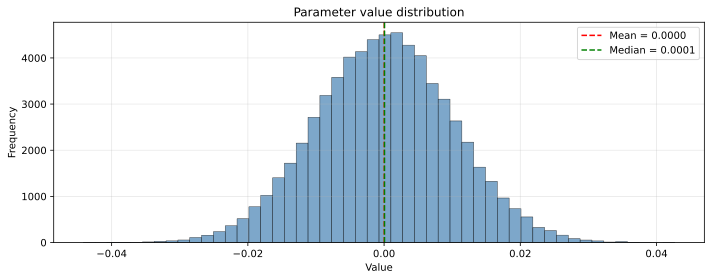

Shape: torch.Size([256])  |  Total elements: 256
Min: 0.000000  |  Max: 0.000000
Mean: 0.000000  |  Std: 0.000000
Median: 0.000000  |  IQR: 0.000000
Skewness: nan  |  Kurtosis: nan
Non-zero ratio: 0.0000%  |  |value| mean: 0.000000


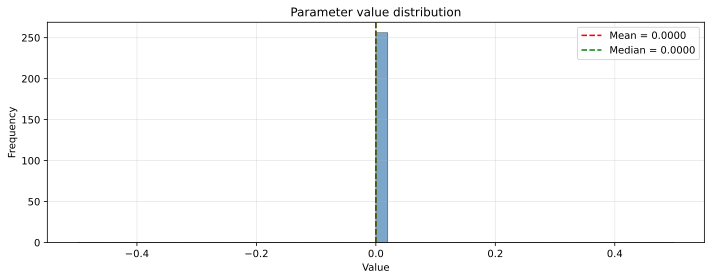

In [84]:
for i in range(3):
    analyze_parameter_tensor(model_r.params[i], plot_hist=True, show_stats=True);

在 GRU 中，重置门计算公式为：
$$r_t = σ( W_xr * x_t + W_hr * h_{t-1} + b_r )$$

<span style="color:red;font-weight:600;font-size:15px">仅重置门时, W_xr, W_hr 几乎为0 (-0.04 ~ 0.04), b_r 直接为 0 (训练了两次都是)</span>, 这会使 r_t 更接近 0。这意味着：
- 在标准 GRU 中，重置门倾向于部分开启
- 去掉更新门后，重置门被训练得几乎总是关闭（r_t ≈ 0）. GRU 的候选隐藏状态公式为：
    $$h̃_t = tanh( W_xh * x_t + W_hh * (r_t ⊙ h_{t-1}) + b_h )$$
    若 r_t ≈ 0，则 r_t ⊙ h_{t-1} ≈ 0，候选状态变为：
    $$h̃_t ≈ tanh( W_xh * x_t + b_h )$$
    即完全忽略上一时刻的隐藏状态，GRU 退化为一个与时间无关的静态映射（类似于无状态的 MLP）

2. 仅更新门(z)

In [30]:
def get_params_z(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device)*0.01

    def three():
        return (normal((num_inputs, num_hiddens)),
                normal((num_hiddens, num_hiddens)),
                torch.zeros(num_hiddens, device=device))

    W_xz, W_hz, b_z = three()  # 更新门参数
    W_xh, W_hh, b_h = three()  # 候选隐状态参数(去掉重置门时W_hh无用)
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xz, W_hz, b_z, W_xh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

In [31]:
def gru_z(inputs, state, params):
    W_xz, W_hz, b_z, W_xh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X in inputs:
        Z = torch.sigmoid((X @ W_xz) + (H @ W_hz) + b_z)
        H_tilda = torch.tanh((X @ W_xh) + b_h)
        H = Z * H + (1 - Z) * H_tilda
        Y = H @ W_hq + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

困惑度 5.3, 134336.2 词元/秒 cpu
time traveller and the the the the the the the the the the the t
traveller and the the the the the the the the the the the t


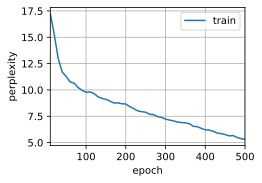

In [71]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1
model_z = d2l.RNNModelScratch(len(vocab), num_hiddens, device, get_params_z,
                            init_gru_state, gru_z)
d2l.train_ch8(model_z, train_iter, vocab, lr, num_epochs, device)

In [74]:
model_z.params[:3]

[tensor([[ 2.7204e-03,  1.3801e-02, -1.7731e-02,  ...,  2.5324e-02,
           7.3974e-04,  1.4428e-02],
         [-1.4821e-02, -2.5666e-01, -3.4848e-01,  ...,  1.9168e-01,
          -2.7525e-02, -1.3361e-01],
         [-3.9162e-02, -9.8341e-02, -5.6595e-02,  ...,  4.0130e-02,
          -1.1252e-02,  2.7806e-02],
         ...,
         [-8.4341e-04, -1.0792e-02,  4.0975e-03,  ...,  1.5705e-02,
           9.1263e-03,  2.0570e-02],
         [ 6.2650e-03,  4.6496e-02,  1.9674e-02,  ..., -3.0251e-02,
           5.8155e-03, -1.5690e-02],
         [ 4.9668e-04,  4.6931e-05, -8.3129e-04,  ..., -3.4696e-03,
           7.4918e-03,  6.6242e-04]], requires_grad=True),
 tensor([[ 0.0165, -0.0232,  0.0237,  ..., -0.0815,  0.0134, -0.0181],
         [-0.0075,  0.1263,  0.0276,  ...,  0.4930, -0.0202, -0.0503],
         [-0.0465,  0.0038,  0.0502,  ..., -0.1560, -0.1046,  0.1281],
         ...,
         [-0.0253,  0.1210,  0.0061,  ...,  0.1630, -0.0263, -0.1898],
         [-0.0005,  0.0594,  0.0035,

In [35]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from typing import Optional

def analyze_parameter_tensor(
    tensor: torch.Tensor,
    name: Optional[str] = None,
    plot_hist: bool = True,
    bins: int = 50,
    figsize: tuple = (10, 4),
    show_stats: bool = True,
    show_values: bool = False,
    num_values: int = 10,
) -> dict:
    """
    分析神经网络参数张量的统计特性（适用于权重、偏置等）。
    
    Args:
        tensor: 待分析的 torch.Tensor
        name: 参数名称（如 'layer1.weight'），用于打印和标题
        plot_hist: 是否绘制直方图
        bins: 直方图的 bin 数量
        figsize: 图像大小（宽, 高）
        show_stats: 是否打印统计摘要
        show_values: 是否显示前几个元素的值
        num_values: 若 show_values=True，显示的元素个数
        
    Returns:
        dict: 包含统计信息的字典
    """
    # 处理设备、梯度
    if tensor.is_cuda:
        tensor = tensor.cpu()
    if tensor.requires_grad:
        tensor = tensor.detach()
    
    # 展平为一维数组以便统计
    flat = tensor.flatten().numpy()
    
    # 计算统计量
    min_val = flat.min()
    max_val = flat.max()
    mean_val = flat.mean()
    std_val = flat.std()
    median_val = np.median(flat)
    q25 = np.percentile(flat, 25)
    q75 = np.percentile(flat, 75)
    iqr = q75 - q25
    skewness = stats.skew(flat)
    kurtosis = stats.kurtosis(flat)
    # 非零比例（稀疏度）
    nonzero_ratio = np.count_nonzero(flat) / flat.size
    # 绝对值均值（L1 范数均值）
    abs_mean = np.abs(flat).mean()
    
    stats_dict = {
        'shape': tensor.shape,
        'numel': flat.size,
        'min': min_val,
        'max': max_val,
        'mean': mean_val,
        'std': std_val,
        'median': median_val,
        'q25': q25,
        'q75': q75,
        'iqr': iqr,
        'skewness': skewness,
        'kurtosis': kurtosis,
        'nonzero_ratio': nonzero_ratio,
        'abs_mean': abs_mean,
    }
    
    if show_stats:
        print("=" * 60)
        if name:
            print(f"Parameter: {name}")
        print(f"Shape: {tensor.shape}  |  Total elements: {flat.size:,}")
        print(f"Min: {min_val:.6f}  |  Max: {max_val:.6f}")
        print(f"Mean: {mean_val:.6f}  |  Std: {std_val:.6f}")
        print(f"Median: {median_val:.6f}  |  IQR: {iqr:.6f}")
        print(f"Skewness: {skewness:.4f}  |  Kurtosis: {kurtosis:.4f}")
        print(f"Non-zero ratio: {nonzero_ratio:.4%}  |  |value| mean: {abs_mean:.6f}")
        print("=" * 60)
    
    if show_values:
        # 显示前 num_values 个元素（展平后的）
        sample_vals = flat[:num_values]
        print(f"First {min(num_values, len(sample_vals))} values: {sample_vals}")
    
    if plot_hist:
        plt.figure(figsize=figsize)
        # 根据数据分布特性选择合适的颜色和透明度
        plt.hist(flat, bins=bins, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
        # 添加均值、中位数线
        plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean = {mean_val:.4f}')
        plt.axvline(median_val, color='green', linestyle='dashed', linewidth=1.5, label=f'Median = {median_val:.4f}')
        plt.xlabel('Value')
        plt.ylabel('Frequency')
        title = f"Histogram of {name}" if name else "Parameter value distribution"
        plt.title(title)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    return stats_dict

Shape: torch.Size([28, 256])  |  Total elements: 7,168
Min: -0.927811  |  Max: 1.125256
Mean: -0.003641  |  Std: 0.076036
Median: -0.002726  |  IQR: 0.034083
Skewness: 1.3301  |  Kurtosis: 49.7708
Non-zero ratio: 100.0000%  |  |value| mean: 0.036650


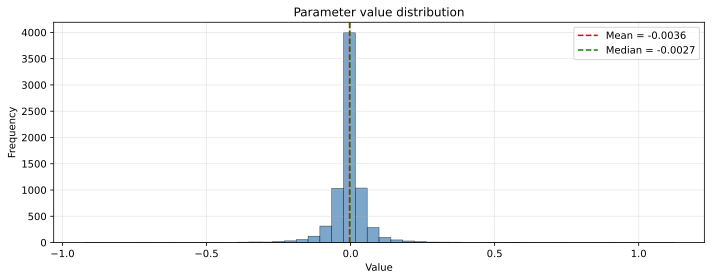

Shape: torch.Size([256, 256])  |  Total elements: 65,536
Min: -1.277112  |  Max: 0.970403
Mean: -0.000662  |  Std: 0.076681
Median: 0.000069  |  IQR: 0.052816
Skewness: -0.2712  |  Kurtosis: 16.8294
Non-zero ratio: 100.0000%  |  |value| mean: 0.046378


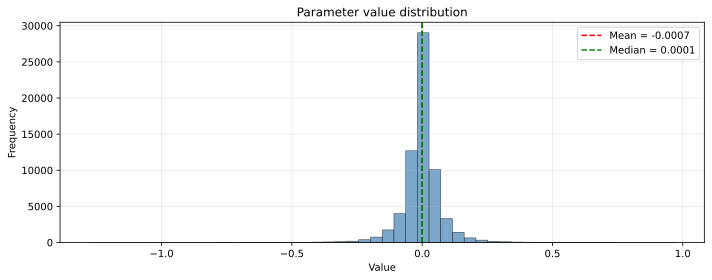

Shape: torch.Size([256])  |  Total elements: 256
Min: -0.967439  |  Max: 0.355843
Mean: -0.100282  |  Std: 0.193006
Median: -0.056080  |  IQR: 0.151315
Skewness: -1.7427  |  Kurtosis: 4.9832
Non-zero ratio: 100.0000%  |  |value| mean: 0.138161


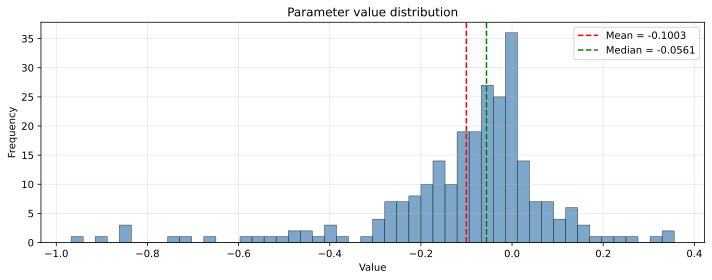

In [76]:
for i in range(3):
    analyze_parameter_tensor(model_z.params[i], plot_hist=True, show_stats=True)

**权重分布形态对比：从“尖峰”到“极端尖峰”**
|参数	|正常 GRU (峰度)	|去掉重置门的 GRU (峰度)	|关键变化 |
|------|------|------|------|
|W_xz (输入权重)	|16.88	|49.77	|峰度激增 3 倍|
|W_hz (隐状态权重)	|5.76	|16.83	|峰度激增 3 倍|
|b_z (偏置)	|5.02	|4.98	|基本持平

峰度暴增意味着“赢家通吃”：当重置门被移除后，更新门成为唯一的门控单元，必须同时负责“保留历史”和“融合新信息”。这导致少数权重的绝对值被放大（长尾加重），而绝大多数权重进一步向均值收缩，形成极其陡峭的分布中心峰（Kurtosis 49.77 是统计学意义上的极端离群分布）

注: 分布形态揭示了功能压力. 在深度学习中，**极高的峰度（Kurtosis > 20）通常是参数冗余或功能过载的标志**。去掉重置门后的 W_xz 呈现 49.77 的峰度，说明这 28x256 的矩阵中，只有极少数的连接在做真正有效的门控决策，其余大部分参数是“沉默的大多数”。

下面将256个隐藏单元减少到64个,可以看到峰度降低

困惑度 5.4, 210337.3 词元/秒 cpu
time traveller the the the the the the the the the the the the t
traveller the the the the the the the the the the the the t


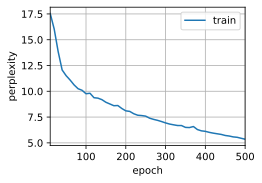

In [89]:
vocab_size, num_hiddens_64, device = len(vocab), 64, d2l.try_gpu()
num_epochs, lr = 500, 1
model_z_64 = d2l.RNNModelScratch(len(vocab), num_hiddens_64, device, get_params_z,
                            init_gru_state, gru_z)
d2l.train_ch8(model_z_64, train_iter, vocab, lr, num_epochs, device)

Shape: torch.Size([28, 64])  |  Total elements: 1,792
Min: -1.362180  |  Max: 1.528283
Mean: -0.007760  |  Std: 0.200179
Median: -0.005215  |  IQR: 0.111922
Skewness: 0.0845  |  Kurtosis: 10.2796
Non-zero ratio: 100.0000%  |  |value| mean: 0.115096


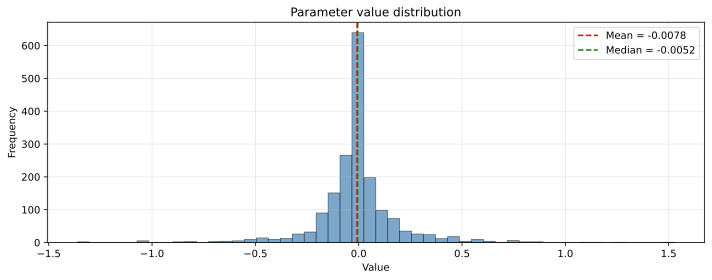

Shape: torch.Size([64, 64])  |  Total elements: 4,096
Min: -1.546995  |  Max: 1.580973
Mean: -0.008090  |  Std: 0.286083
Median: -0.004438  |  IQR: 0.279951
Skewness: 0.0797  |  Kurtosis: 2.8849
Non-zero ratio: 100.0000%  |  |value| mean: 0.201335


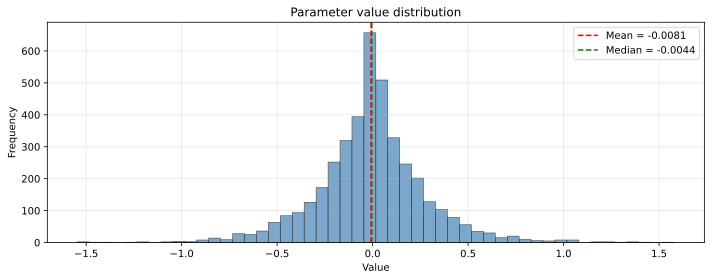

Shape: torch.Size([64])  |  Total elements: 64
Min: -1.107391  |  Max: 0.296714
Mean: -0.217532  |  Std: 0.345670
Median: -0.166855  |  IQR: 0.445258
Skewness: -0.7616  |  Kurtosis: -0.3257
Non-zero ratio: 100.0000%  |  |value| mean: 0.293620


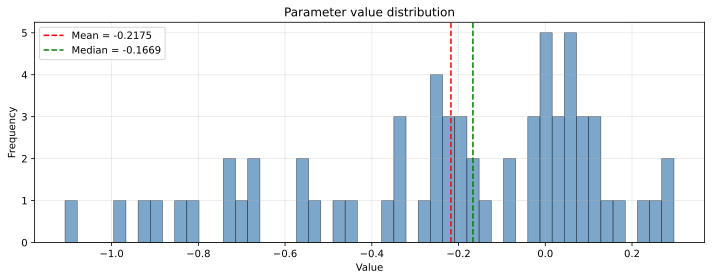

In [90]:
for i in range(3):
    analyze_parameter_tensor(model_z_64.params[i], plot_hist=True, show_stats=True)